# Validate fire products against ground-truth references

This notebook is the **accuracy** companion to `run_fire_comparison.ipynb`. That
notebook asks *"do the products agree with each other?"* (no truth). This one asks
*"is a product **right**?"* — it scores each remotely-sensed product against
independent reference fire perimeters (NIFC large fires, TNC preserve burns,
NCWRC prescribed fires) curated with Margaret's help.

**What the metrics mean (read this first):**
- **recall = 1 − omission** is the headline number: of a known fire's footprint,
  the fraction the product detected. Clean, because a fire definitely occurred
  inside the perimeter.
- **precision** is reported only *per event, inside a buffered window*, and is
  **conditional**: the references are not a complete census (a product burn
  outside them may be a real small fire, not a false alarm), and a perimeter is
  an *outer boundary* that includes unburned islands (it overestimates truth).
- Scoring is **time-matched, per event** — each incident vs the product layer for
  its own year. Active fire (VIIRS) is judged at the event level (`detected`),
  and is 2012+ so it is simply absent for the older fires.

See `decisions.md` → *Ground-truth validation toolkit* for the full rationale.

## 0. Setup & AOI

In [51]:
%load_ext autoreload
%autoreload 2

import warnings
import geopandas as gpd
import matplotlib.pyplot as plt
import dataframe_image as dfi
import pandas as pd

from peatfire import data_path
from peatfire.fire_products_comparison import (
    list_references, get_reference, load_reference, reference_event_table,
    validate_event, validate_products, summarize_validation, recall_matrix,
    confusion_scores, rasterize_polygons_to_grid, build_common_grid,
    stack_on_common_grid, list_products,
    set_fire_style, plot_validation_heatmap,
    plot_reference_vs_product_for_one_event, plot_event_perimeter,
    overlay_aoi_boundaries,
)

set_fire_style()

# AOI: swap this path for NC peatlands / non-peatlands later -- nothing else changes.
aoi_nc = gpd.read_file(data_path("processed", "boundaries", "nc_boundary.gpkg"))
aoi_nc_peat = gpd.read_file(data_path("processed", "peat_extent", "nc_peatlands_aoi.gpkg"))
aoi_nc_peat_80_histosol = gpd.read_file(data_path("processed", "peat_extent", "nc_peatlands_80_histosol_aoi.gpkg"))

# set which aoi you want to run fire analyses for
aoi_mapping = {
    'nc_peat_80_histosol': aoi_nc_peat_80_histosol,
    'aoi_nc': aoi_nc,
    'aoi_nc_peat': aoi_nc_peat
}

aoi_name = "nc_peat_80_histosol"
aoi = aoi_mapping[aoi_name]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. What references are registered, and what's on disk?

Each reference is a vector source of fire perimeters. A source whose folder is
missing skips with a warning (like the products), so this runs on whatever you've
downloaded. Expected processed layout (clip the raw NIFC gpkgs in
`download_and_clip_data.ipynb` first):

```
data/processed/fire/reference/nifc_ifph/nifc_ifph_*.gpkg   # default NIFC source
data/processed/fire/reference/geomac/geomac_*.gpkg         # 2000-2018 cross-check
data/processed/fire/reference/tnc_burns/tnc_burns_*.shp
```

In [52]:
rows = []
for name in list_references():
    s = get_reference(name)
    n = len(sorted(s.directory.glob(s.glob))) if s.directory.exists() else 0
    rows.append({"reference": name, "kind": s.kind, "dir_exists": s.directory.exists(),
                 "n_files": n, "directory": str(s.directory)})
pd.DataFrame(rows).set_index("reference")

,kind,dir_exists,n_files,directory
reference,,,,
NIFC_IFPH,perimeter,True,1,/Users/jinjiang-macair/Library/CloudStorage/On...
GEOMAC,perimeter,True,1,/Users/jinjiang-macair/Library/CloudStorage/On...
TNC_SANDHILLS,perimeter,True,1,/Users/jinjiang-macair/Library/CloudStorage/On...
TNC_COASTAL_PLAIN,perimeter,True,1,/Users/jinjiang-macair/Library/CloudStorage/On...
NCWRC_RX,perimeter,False,0,/Users/jinjiang-macair/Library/CloudStorage/On...


## 2. The event menu

`reference_event_table` lists every incident in the source within the AOI — your
menu of fires to validate against, and where to find Margaret's named events
(Evans Road 2008, Pains Bay 2011, Juniper Road 2011, Whipping Creek 2016,
Great Lakes 2023, ...).

## 3. Validate one event in detail

`validate_event` takes one perimeter row, builds a buffered analysis-window grid
around it, rasterises the perimeter to the "reference burned" mask, loads every
product on that same grid for the event's year, and returns per-product
recall / precision / detected. Pick a Margaret fire by name.

In [53]:
products = list_products("burned_area")
products

['MCD64A1', 'GABAM', 'FireCCI51', 'FireCCIS311']

In [54]:
ref = load_reference("NIFC_IFPH", aoi)
if ref is not None:
    # pick one event by name substring (case-insensitive); fall back to the first row
    hit = ref[ref["_event"].str.contains("Evans Road", case=False, na=False)]
    event_gdf = hit if len(hit) else ref.iloc[[0]]
    year = int(event_gdf["_year"].iloc[0])
    print("event:", event_gdf["_event"].iloc[0], "| year:", year)
    detail_one = validate_event(
        event_gdf,
        products=list_products("burned_area") + list_products("occurrence"),
        year=year, buffer_km=5.0,
    )
    display(detail_one[["event", "year", "product", "family",
                        "recall", "precision", "detected", "n_ref", "n_prod"]])
else:
    print("NIFC_IFPH not downloaded yet — skipping.")

event: Carolina Bay | year: 2009


,event,year,product,family,recall,precision,detected,n_ref,n_prod
0,Carolina Bay,2009,MCD64A1,burned_area,0.7,0.451613,True,20,31
1,Carolina Bay,2009,GABAM,burned_area,0.0,0.000000,False,20,23
2,Carolina Bay,2009,FireCCI51,burned_area,0.0,NaN,False,20,0


## 3b. *See* one event vs a product on a map

The table above gives the numbers; this puts them on a map. For a chosen
reference event, `plot_reference_vs_product_for_one_event` time-matches the
product, rasterises the perimeter onto the **same common grid**, and draws the
reference-vs-product **confusion overlay** (the categorical encoding reused from
`plot_overlay_map`): blue = reference only (**omission** — the product missed
it), red = product only (commission), purple = **both** (hit). The actual event
perimeter is outlined on top, and `aoi_context` (e.g. the NC outline) is drawn
for geographic reference — generalising the manual "overlay `aoi_nc`, then
restore the view" step into `overlay_aoi_boundaries`.

`extent="event"` (default) zooms to a `buffer_km` window so a single incident is
legible; `extent="aoi"` maps the whole AOI as the backdrop instead. The figure is
saved with the event name in the filename when `out_dir` is given.

In [55]:
events = ['Deep Creek']
products = list_products("burned_area") + list_products("occurrence")
ba = set(list_products("burned_area"))          # compute once, not per product

for event in events:
    for ref in list_references():
        try:
            # "Where is this fire?" -- perimeter only, no product/grid
            fig = plot_event_perimeter(
                reference=ref, aoi=aoi, event=event,
                fill=True, aoi_context=aoi, aoi_name=aoi_name,
                out_dir="../outputs/figures/fire",
            )
            plt.close(fig)
        except ValueError:
            # this reference doesn't contain this event (or it's outside the AOI)
            continue                            # -> skip the products too: same miss

        for product in products:
            try:
                fig = plot_reference_vs_product_for_one_event(
                    reference=ref, product=product, aoi=aoi, aoi_name=aoi_name, event=event,
                    binary=product in ba,        # BA -> confusion overlay; else raster
                    extent="event", buffer_km=10.0,
                    aoi_context=aoi,
                    out_dir="../outputs/figures/fire",
                )
                plt.close(fig)
            except ValueError:
                continue

/Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/src/peatfire/fire_products_comparison/reference_sources.py:300: UserWarning: NCWRC_RX: directory /Users/jinjiang-macair/Library/CloudStorage/OneDrive-DukeUniversity/Duke/TNC/peat_fire_stanback/data/processed/fire/reference/ncwrc_rx does not exist -- skipping.
  gdf = _read_all(spec)


## 4. Validate across all events of a source

`validate_products` runs every event of a reference, time-matched, and returns one
tidy row per (event, product). `min_acres` focuses on mappable incidents;
`match="month"` tightens timing when the source carries dates.

In [56]:
detail = validate_products(
    "NIFC_IFPH", aoi,
    products=["MCD64A1", "GABAM", "FireCCI51", "FireCCIS311", "VIIRS"],
    buffer_km=5.0, min_acres=100.0, match="year",
)
detail.head(20) if not detail.empty else "no events scored (source not downloaded?)"

,source,event,year,month,product,family,tp,fn,fp,n_ref,n_prod,recall,precision,detected
0,NIFC_IFPH,Carolina Bay,2009,None,MCD64A1,burned_area,14,6,17,20,31,0.700000,0.451613,True
1,NIFC_IFPH,Carolina Bay,2009,None,GABAM,burned_area,0,20,23,20,23,0.000000,0.000000,False
2,NIFC_IFPH,Carolina Bay,2009,None,FireCCI51,burned_area,0,20,0,20,0,0.000000,NaN,False
3,NIFC_IFPH,Gum Branch,2010,None,MCD64A1,burned_area,0,8,0,8,0,0.000000,NaN,False
4,NIFC_IFPH,Gum Branch,2010,None,GABAM,burned_area,0,8,0,8,0,0.000000,NaN,False
5,NIFC_IFPH,Gum Branch,2010,None,FireCCI51,burned_area,0,8,0,8,0,0.000000,NaN,False
6,NIFC_IFPH,Peak Swamp,2012,None,MCD64A1,burned_area,2,4,76,6,78,0.333333,0.025641,True
7,NIFC_IFPH,Peak Swamp,2012,None,GABAM,burned_area,1,5,67,6,68,0.166667,0.014706,True
8,NIFC_IFPH,Peak Swamp,2012,None,FireCCI51,burned_area,4,2,67,6,71,0.666667,0.056338,True
9,NIFC_IFPH,Peak Swamp,2012,None,VIIRS,occurrence,0,6,31,6,31,0.000000,0.000000,False


## 5. Per-product roll-up

`recall_pooled` is cell-weighted (dominated by the big fires — "what fraction of
burned *area* was caught?"). `recall_mean_event` weights each fire equally
(surfaces small-fire omission). `detection_rate` = fraction of fires the product
saw at all. The precision column is the conditional within-window number.

In [46]:
_METRIC_COLS = ["recall_pooled", "recall_mean_event", "detection_rate", "precision_mean_event"]

def style_validation(summary: pd.DataFrame):
    """Same viridis 0->1 scale as plot_validation_heatmap, for notebook display."""
    cols = [c for c in _METRIC_COLS if c in summary.columns]
    return (
        summary.style
        .background_gradient(cmap="viridis", vmin=0.0, vmax=1.0, subset=cols)
        .format("{:.3f}")
    )

In [47]:
if not detail.empty:
    styled = style_validation(summarize_validation(detail))
    display(styled)   # optional: inline render in the notebook
    dfi.export(
        styled,
        '../outputs/figures/fire/nifc_ifph_burned_area_validation_summary.png',
        dpi=150,
        table_conversion="matplotlib",   # no browser, no event-loop clash
    )

,n_events,recall_pooled,recall_mean_event,detection_rate,precision_mean_event
product,,,,,
MCD64A1,20.000,0.773,0.273,0.400,0.589
FireCCI51,13.000,0.740,0.183,0.231,0.618
FireCCIS311,12.000,0.724,0.262,0.417,0.555
GABAM,15.000,0.501,0.096,0.200,0.371
VIIRS,18.000,0.284,0.134,0.611,0.605


## 6. Events × products recall heatmap

Each row is one reference fire, each column a product — so per-incident strengths
and weaknesses read straight off. (e.g. does any product miss the escaped-Rx Dad
Fire, which only shows a remote signal for ~a year?)

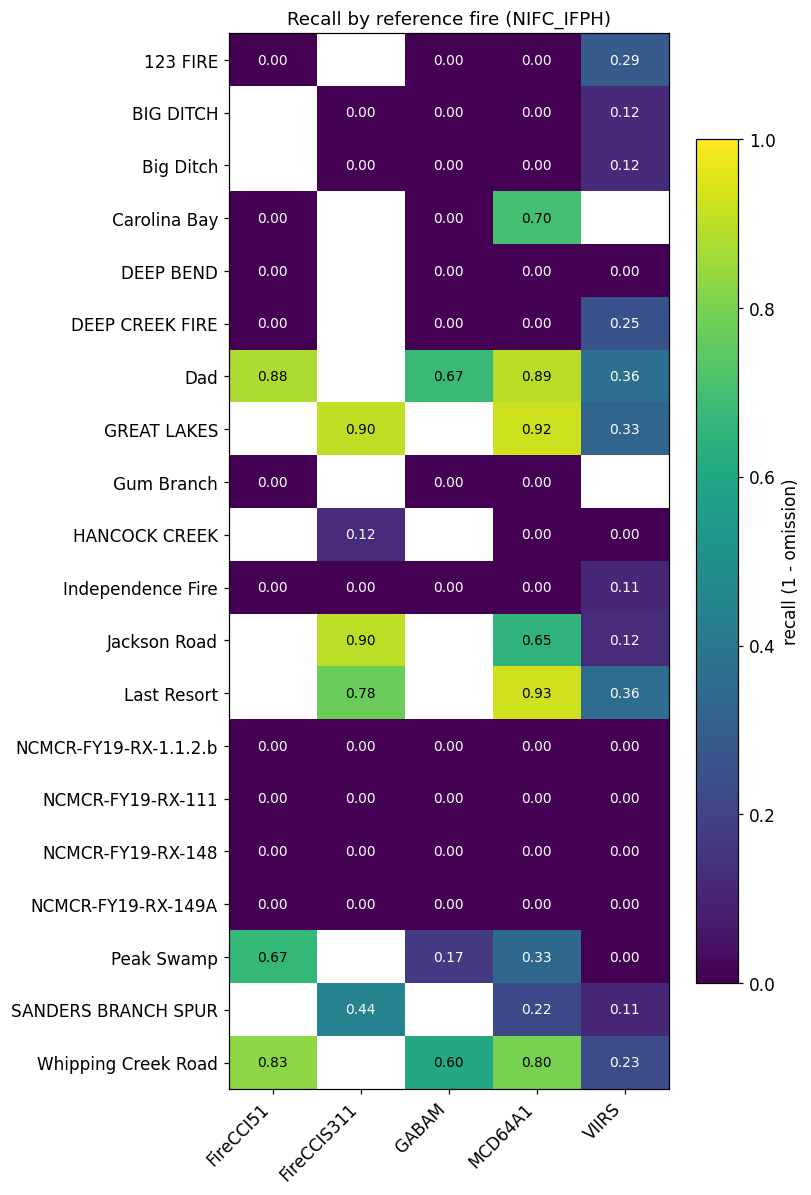

In [48]:
if not detail.empty:
    m = recall_matrix(detail, value="recall")
    plot_validation_heatmap(m, title="Recall by reference fire (NIFC_IFPH)")
    plt.savefig(f"../outputs/figures/fire/validation_recall_nifc_ifph_{aoi_name}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

## 7. Small-fire references (TNC / NCWRC)

TNC preserve burns and NCWRC prescribed fires are *small* — a stress test of the
small-fire omission that coarse products (MCD64A1 500 m) are expected to fail.
Compare `recall_mean_event` here against the big-fire NIFC table above.

In [49]:
for src in ["TNC_SANDHILLS", "TNC_COASTAL_PLAIN", "NCWRC_RX"]:
    d = validate_products(src, aoi, products=["MCD64A1", "GABAM", "FireCCI51", "FireCCIS311", "VIIRS"])
    if d.empty:
        print(f"{src}: not downloaded — skipping"); continue
    print(f"=== {src} ===")
    
    styled = style_validation(summarize_validation(d).round(3))
    display(styled)   # optional: inline render in the notebook
    dfi.export(
        styled,
        f'../outputs/figures/fire/{src}_burned_area_validation_summary.png',
        dpi=150,
        table_conversion="matplotlib",   # no browser, no event-loop clash
    )

TNC_SANDHILLS: not downloaded — skipping


KeyboardInterrupt: 

## 8. GeoMAC cross-check (do NOT pool with NIFC_IFPH)

GeoMAC (2000-2018) overlaps NIFC_IFPH, so the *same* fire is in both — pooling
double-counts. Run it separately as an independent cross-check on those years.

In [39]:
d_geomac = validate_products("GEOMAC", aoi,
                             products=["MCD64A1", "GABAM", "FireCCI51", "FireCCIS311", "VIIRS"],
                             years=range(2000, 2019), min_acres=100.0)
if not d_geomac.empty:
    styled = style_validation(summarize_validation(d_geomac).round(3))
    display(styled)   # optional: inline render in the notebook
    dfi.export(
        styled,
        '../outputs/figures/fire/geomac_burned_area_validation_summary.png',
        dpi=150,
        table_conversion="matplotlib",   # no browser, no event-loop clash
    )

,n_events,recall_pooled,recall_mean_event,detection_rate,precision_mean_event
product,,,,,
FireCCI51,13.000,0.898,0.711,0.769,0.664
MCD64A1,13.000,0.845,0.610,0.769,0.723
GABAM,13.000,0.831,0.673,0.769,0.631
VIIRS,5.000,0.240,0.330,0.800,0.766


## 9. Note on severity

Perimeters carry **no severity** and we have no field CBI, so severity products
(SE FireMap, MOSEV, MTBS) are *not* scored here. Their proper validation use is to
**restrict the severity cross-comparison to reference cells** — i.e. compare them
only where a fire is known to have burned. Do that in `run_fire_comparison.ipynb`
by intersecting the severity stack with a rasterised reference mask
(`rasterize_polygons_to_grid`).

In [ ]:
import geopandas as gpd
from peatfire import data_path

for f in [data_path('raw', 'fire', 'reference', 'TNC_NC_Sandhills_Fire_History_2025', 'TNC_NC_Sandhills_Fire_History_2025.shp'),
          data_path('raw', 'fire', 'reference', 'TNC_NC_Coastal_Plain_Fire_History_2025', 'TNC_NC_Coastal_Plain_Fire_History_2025.shp')]:
    
    g = gpd.read_file(f, rows=1)
    print(g.crs, list(g.columns))

EPSG:3857 ['START_DATE', 'PRESERVE', 'BURN_UNIT', 'ACREAGE', 'BURN_BOSS', 'TYPE_OF_BU', 'Drone', 'FIRE_TREAT', 'END_DATE', 'COMMENTS', 'YEAR', 'COUNTY', 'RESTORATIO', 'MONTH', 'Shape__Len', 'Shape__Are', 'geometry']
EPSG:3857 ['START_DATE', 'PRESERVE', 'BURN_UNIT', 'ACREAGE', 'BURN_BOSS', 'TYPE_OF_BU', 'Drone', 'COUNTY', 'FIRE_TREAT', 'Year', 'COMMENTS', 'END_DATE', 'RESTORATIO', 'Shape__Len', 'Shape__Are', 'geometry']
